<a href="https://colab.research.google.com/github/abuzar01440/abuzar-portfolio/blob/main/British%20airline%20scrapping%20and%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

---

## Web scraping and analysis

This Jupyter notebook includes some code to get you started with web scraping. We will use a package called `BeautifulSoup` to collect the data from the web. Once you've collected your data and saved it into a local `.csv` file you should start with your analysis.

### Scraping data from Skytrax

If you visit [https://www.airlinequality.com] you can see that there is a lot of data there. For this task, we are only interested in reviews related to British Airways and the Airline itself.

If you navigate to this link: [https://www.airlinequality.com/airline-reviews/british-airways] you will see this data. Now, we can use `Python` and `BeautifulSoup` to collect all the links to the reviews and then to collect the text data on each of the individual review links.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
base_url = "https://www.airlinequality.com/airline-reviews/british-airways"
pages = 10
page_size = 100

reviews = []

# for i in range(1, pages + 1):
for i in range(1, pages + 1):

    print(f"Scraping page {i}")

    # Create URL to collect links from paginated data
    url = f"{base_url}/page/{i}/?sortby=post_date%3ADesc&pagesize={page_size}"

    # Collect HTML data from this page
    response = requests.get(url)

    # Parse content
    content = response.content
    parsed_content = BeautifulSoup(content, 'html.parser')
    for para in parsed_content.find_all("div", {"class": "text_content"}):
        reviews.append(para.get_text())

    print(f"   ---> {len(reviews)} total reviews")

Scraping page 1
   ---> 100 total reviews
Scraping page 2
   ---> 200 total reviews
Scraping page 3
   ---> 300 total reviews
Scraping page 4
   ---> 400 total reviews
Scraping page 5
   ---> 500 total reviews
Scraping page 6
   ---> 600 total reviews
Scraping page 7
   ---> 700 total reviews
Scraping page 8
   ---> 800 total reviews
Scraping page 9
   ---> 900 total reviews
Scraping page 10
   ---> 1000 total reviews


In [ ]:
df = pd.DataFrame()
df["reviews"] = reviews
df.head()

,reviews
0,"✅ Trip Verified | The seats were excellent, ..."
1,✅ Trip Verified | After the nightmare of get...
2,✅ Trip Verified | Prior to boarding a gate a...
3,✅ Trip Verified | I flew from Amsterdam to L...
4,"✅ Trip Verified | First the good news, the clu..."


Congratulations! Now you have your dataset for this task! The loops above collected 1000 reviews by iterating through the paginated pages on the website. However, if you want to collect more data, try increasing the number of pages!

 The next thing that you should do is clean this data to remove any unnecessary text from each of the rows. For example, "✅ Trip Verified" can be removed from each row if it exists, as it's not relevant to what we want to investigate.

In [ ]:
import os

   # Create the 'data' directory if it doesn't exist
if not os.path.exists("data"):
       os.makedirs("data")

   # Now you can save the DataFrame to the CSV file
df.to_csv("data/BA_reviews.csv")

In [ ]:
df = pd.read_csv("data/BA_reviews.csv")
df

,Unnamed: 0,reviews
0,0,"✅ Trip Verified | The seats were excellent, ..."
1,1,✅ Trip Verified | After the nightmare of get...
2,2,✅ Trip Verified | Prior to boarding a gate a...
3,3,✅ Trip Verified | I flew from Amsterdam to L...
4,4,"✅ Trip Verified | First the good news, the clu..."
...,...,...
995,995,✅ Trip Verified | Sydney to London via Singap...
996,996,Not Verified | London to Johannesburg. Britis...
997,997,✅ Trip Verified | I have to say travelling in ...
998,998,Not Verified | I had a stress free journey wi...


In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df

,reviews
0,"✅ Trip Verified | The seats were excellent, ..."
1,✅ Trip Verified | After the nightmare of get...
2,✅ Trip Verified | Prior to boarding a gate a...
3,✅ Trip Verified | I flew from Amsterdam to L...
4,"✅ Trip Verified | First the good news, the clu..."
...,...
995,✅ Trip Verified | Sydney to London via Singap...
996,Not Verified | London to Johannesburg. Britis...
997,✅ Trip Verified | I have to say travelling in ...
998,Not Verified | I had a stress free journey wi...


In [ ]:
def check_verified_number(text):
    """
    Calculates the number of verified and non-verified trips in a given text.

    Args:
        text: The input string containing trip verification information.

    Returns:
        A tuple containing (verified_count, non_verified_count).
    """
    verified_count = 0
    non_verified_count = 0

    if "✅ Trip Verified" in text:
        verified_count += 1
    elif "not verified" in text:
        non_verified_count += 1
    else:
        non_verified_count += 1

    return (verified_count, non_verified_count)


verified_total = 0
non_verified_total = 0

for review in df.reviews:
    verified, non_verified = check_verified_number(review)
    verified_total += verified
    non_verified_total += non_verified

print(f"Total Verified: {verified_total}")
print(f"Total Non-Verified: {non_verified_total}")

Total Verified: 741
Total Non-Verified: 259


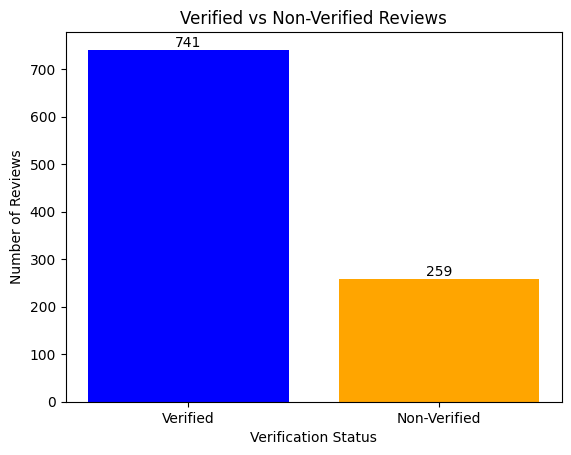

In [ ]:
Total_Verified=741
Total_NonVerified= 259
# bar chart of verified and non verified
import matplotlib.pyplot as plt

ax=plt.bar(['Verified', 'Non-Verified'], [Total_Verified, Total_NonVerified], color =["blue", "orange"])
plt.bar_label(ax)
plt.xlabel('Verification Status')
plt.ylabel('Number of Reviews')
plt.title('Verified vs Non-Verified Reviews')
plt.show()